In [52]:
import json

import gc_utils
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [ ]:
sim = "m12m"
sim_dir = "/Users/z5114326/Documents/simulations/"
sim_dir = "/Volumes/Expansion/simulations/"

all_data = sim_dir + sim + "/" + sim + "_res7100/snapshot_times.txt"
all_snaps = pd.read_table(all_data, comment="#", header=None, sep=r"\s+")
all_snaps.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]

proc_file = sim_dir + sim + "/" + sim + "_processed.hdf5"
proc_data = h5py.File(proc_file, "r")  # open processed data file

In [54]:
def fSMHM(x, alpha, delta, gamma):
    if x > -2.0:
        val = -np.log10(10 ** (alpha * x) + 1) + delta * ((np.log10(1 + np.exp(x))) ** gamma) / (
            1 + np.exp(10 ** (-x))
        )
    else:
        val = -np.log10(10 ** (alpha * x) + 1)
    return val

In [55]:
def SMHMparameters(z):  # standard Behroozi relation (Mvir)
    a = 1.0 / (1.0 + z)
    nu = np.exp(-4 * (a**2))

    log_eps = -1.777 + ((-0.006 * (a - 1)) * nu) - (0.119 * (a - 1))
    eps = 10**log_eps

    log_m1 = 11.514 + (-1.793 * (a - 1) + (-0.251 * z)) * nu
    m1 = 10**log_m1

    alpha = -1.412 + (0.713 * (a - 1)) * nu
    delta = 3.508 + (2.608 * (a - 1) + (-0.043 * z)) * nu
    gamma = 0.316 + (1.319 * (a - 1) + (0.279 * z)) * nu
    xi = np.random.normal(0, 0.218 - 0.023 * (a - 1))  # scatter
    return m1, alpha, delta, gamma, eps, xi

In [56]:
def SMHM(Mh, z, k=False, scatter=False, mdef="m200"):
    if not k:
        m1, alpha, delta, gamma, eps, xi = SMHMparameters(z)
    # else:
    #     if mdef == "m200":
    #         m1, alpha, delta, gamma, eps, xi = SMHMparameters2(z)
    #     else:  # Mvir
    #         m1, alpha, delta, gamma, eps, xi = SMHMparameters3(z)
    logSM = np.log10(eps * m1) + fSMHM(np.log10(Mh / m1), alpha, delta, gamma) - fSMHM(0, alpha, delta, gamma)
    if scatter:
        logSM += xi
    SM = 10**logSM
    return SM

In [57]:
def star_mass(Mh, z):
    gaussian_process = True
    # sm_scat = True
    # fix_stellar = False

    if gaussian_process:
        # Evolve sm using Gaussian process
        sm1 = SMHM(Mh, z, scatter=False)
        # if sm_scat:
        #     SM = np.max([sm1 * (10 ** dsm[i]), sm_arr[progIdx]])
        # else:
        #     SM = sm1
        # if "fix_stellar" in params and params["fix_stellar"]:
        #     SM = SM + sm_correct

    return sm1

In [58]:
def gas_mass(SM, Mh, z, sim, sim_dir):
    sim_code_file = sim_dir + "simulation_codes.json"
    with open(sim_code_file, "r") as file:
        sim_codes = json.load(file)
    Ob = sim_codes[sim]["Ob"]
    Om = sim_codes[sim]["Om"]
    fb = Ob / Om

    UVB_constraint = "KM22"

    tdep = 0.3
    sigma_gas = 0.3

    slope = 0.33
    if SM < 1e9:
        slope = 0.19
    log_ratio = 0.05 - 0.5 - slope * (np.log10(SM) - 9.0)  # log10(Mg/M*)
    if z < 3:  # Gas fraction saturates at z > 3
        if z < 2:
            # Strong ssfr evolution at z < 2
            log_ratio += (3.0 - tdep) * np.log10((1.0 + z) / 3.0) + (3.0 - tdep) * np.log10(3.0)
        else:
            # Weak ssfr evolution at z > 2 (Lilly+)
            log_ratio += (1.7 - tdep) * np.log10((1.0 + z) / 3.0) + (3.0 - tdep) * np.log10(3.0)
    else:
        # Weak ssfr evolution at z > 2
        log_ratio += (1.7 - tdep) * np.log10((1.0 + 3) / 3.0) + (3.0 - tdep) * np.log10(3.0)
    # if sigma_gas > 0:
    #     log_ratio += params["rng"].normal(0, sigma_gas)
    ratio = 10**log_ratio
    Mg = SM * ratio
    fstar = SM / (fb * Mh)
    fgas = Mg / (fb * Mh)

    # if params["UVB_constraint"] == "MG10":
    #     # Model extragalactic UVB as in Muratov & Gnedin 2010
    #     Mc = 3.6e9 * np.exp(-0.6 * (1 + z)) / params["h100"]
    #     Mc_min = 1.5e10 * (180 ** (-0.5)) / (params["cosmo"].E(z) * params["h100"])
    #     if Mc < Mc_min:
    #         Mc = Mc_min
    #     fin = 1 / ((1 + (Mc / Mh)) ** 3)

    if UVB_constraint == "KM22":
        # Model extragalactic UVB as in Kravtsov & Manwadkar 2022
        s = lambda x, y: (1 + (2 ** (y / 3) - 1) * (x**y)) ** (-3 / y)
        z_re = 6
        gam = 15
        beta = z_re / (np.log(1.82e3 * np.exp(-0.63 * z_re) - 1)) ** (1 / gam)
        Mc = (
            1.69e10 * np.exp(-0.63 * z) / (1 + np.exp(np.clip((z / beta) ** gam, 0, 500)))
        )  # too large number results in overflow
        fin = s(Mc / Mh, 2)

    else:
        # no constraint
        return Mg

    if fstar + fgas > fin:
        fgas = fin - fstar
        Mg = fgas * fb * Mh

    return Mg

In [59]:
def total_gc_mass(Mh, z, sim, sim_dir, p2=7):
    SM = star_mass(Mh, z)
    Mg = gas_mass(SM, Mh, z, sim, sim_dir)

    sim_code_file = sim_dir + "simulation_codes.json"
    with open(sim_code_file, "r") as file:
        sim_codes = json.load(file)
    Ob = sim_codes[sim]["Ob"]
    Om = sim_codes[sim]["Om"]
    fb = Ob / Om

    # M_gc_tot = 1.8e-4 * p2 * Mg
    M_gc_tot = (3e-5 / fb) * Mg * p2

    return M_gc_tot

In [60]:
halt = gc_utils.get_halo_tree(sim, sim_dir)

Retrieving Halo Tree.....................: 100%|████████████████████████████████████████████████████████████████████████| 1/1 [00:48<00:00, 48.77s/it]


In [61]:
halo_mass_dict = {"time": [], "z": [], "mass": []}

sim_code_file = sim_dir + "simulation_codes.json"
with open(sim_code_file, "r") as file:
    sim_codes = json.load(file)
main_halo = sim_codes[sim]["halo"]
# main_halo = 1920378

for snap in range(10, 601):
    time = all_snaps[all_snaps["index"] == snap]["time_Gyr"].values[0]
    red = all_snaps[all_snaps["index"] == snap]["redshift"].values[0]

    halo_tid = gc_utils.get_halo_prog_at_snap(halt, main_halo, snap)
    halo_idx = np.where(halt["tid"] == halo_tid)[0][0]
    dm_mass = halt["mass"][halo_idx]

    halo_mass_dict["time"].append(time)
    halo_mass_dict["z"].append(red)
    halo_mass_dict["mass"].append(dm_mass)

In [62]:
it_min = 0
it_max = 100

grp_dict = {"time": [], "gc_num_avg": [], "gc_num_std": []}

for time in all_snaps["time_Gyr"].values:
    num_lst = []
    # for it in range(it_min, it_max + 1):
    for it_id in proc_data.keys():
        # it_id = gc_utils.iteration_name(it)proc_data
        src_dat = proc_data[it_id]["source"]
        ana_flag = src_dat["analyse_flag"][()] == 1

        grp_msk = np.abs(src_dat["group_id"][()]) == 0
        # grp_msk = np.abs(src_dat["group_id"][()]) == main_halo
        tfor_msk = src_dat["form_time"][()] <= time
        tdis_msk = (src_dat["t_dis"][()] > time) | (src_dat["t_dis"][()] < 0)

        # t_dis = np.array([td if td > 0 else 10000 for td in src_dat["t_dis"][()]])
        # tdis_msk = t_dis > time

        num_gc = len(src_dat["gc_id"][ana_flag & grp_msk & tfor_msk & tdis_msk])
        num_lst.append(num_gc)

    grp_dict["time"].append(time)
    grp_dict["gc_num_avg"].append(np.average(num_lst))
    grp_dict["gc_num_std"].append(np.std(num_lst))

In [63]:
# Extract and sort by time
t_lst = all_snaps[all_snaps["redshift"] <= 10]["time_Gyr"].to_numpy()
z_lst = all_snaps[all_snaps["redshift"] <= 10]["redshift"].to_numpy()
# snap_lst = all_snaps[all_snaps["redshift"] <= 10]["index"].to_numpy()

# Mh_lst = [1e5, 1e6, 1e7, 1e8, 1e9, 1e10, 1e11]
Mh_lst = [1e9, 1e10, 1e11, 1e12]

SM_lst = [[star_mass(Mh, z) for z in z_lst] for Mh in Mh_lst]
GC_tot_lst = [[total_gc_mass(Mh, z, sim, sim_dir) for z in z_lst] for Mh in Mh_lst]

####### added
sim_code_file = sim_dir + "simulation_codes.json"
with open(sim_code_file, "r") as file:
    sim_codes = json.load(file)
Ob = sim_codes[sim]["Ob"]
Om = sim_codes[sim]["Om"]
fb = Ob / Om

Mg_lst = [1e7, 1e8, 1e9, 1e10]
p2 = 7
GC_test_lst = [(3e-5 / fb) * Mg * p2 for Mg in Mg_lst]

(0.0, 10000.0)

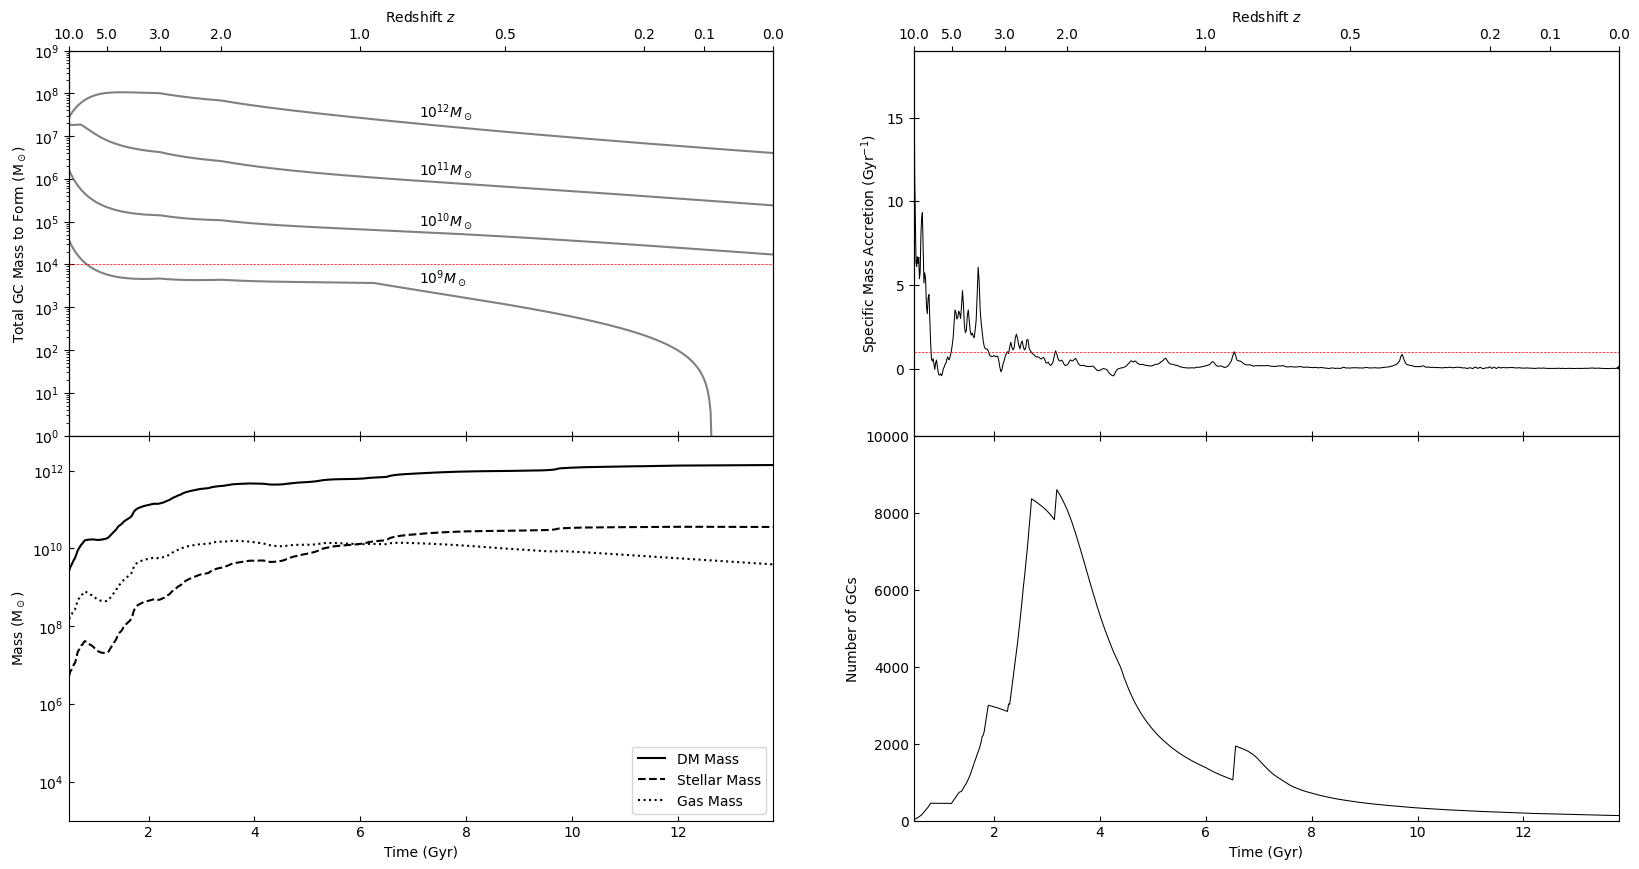

In [66]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(20, 10), sharex=True)
plt.subplots_adjust(hspace=0)
ax01 = axs[0, 0]
ax02 = axs[1, 0]
ax11 = axs[0, 1]
ax12 = axs[1, 1]

for i, Mh in enumerate(Mh_lst):
    gc_tot_vals = np.array(GC_tot_lst[i])
    ax01.plot(t_lst, gc_tot_vals, c="grey")
    # ax01.plot(t_lst, [GC_test_lst[i]] * len(t_lst), c="grey")

    # Add label slightly above the last point
    lab_idx = int(len(t_lst) / 2)
    label_x = t_lst[lab_idx]
    label_y = gc_tot_vals[lab_idx]
    ax01.text(
        label_x + 0.25,
        label_y,
        rf"$10^{{{int(np.log10(Mh))}}}  M_\odot$",
        fontsize=10,
        verticalalignment="bottom",
    )


ax01.plot([np.min(t_lst), np.max(t_lst)], [1e4, 1e4], c="r", ls="--", lw=0.5)

ax01.set_yscale("log")
ax01.set_ylim(1e0, 1e9)
ax01.set_xlim(np.min(t_lst), np.max(t_lst))

ax00 = ax01.twiny()
desired_redshifts = np.array([10, 5, 3, 2, 1, 0.5, 0.2, 0.1, 0])
tick_times = np.interp(desired_redshifts, z_lst[::-1], t_lst[::-1])  # reverse arrays if z decreases with t

ax00.set_xlim(ax01.get_xlim())
ax00.set_xticks(tick_times)
ax00.set_xticklabels([f"{z:.1f}" for z in desired_redshifts])
ax00.set_xlabel("Redshift $z$")

# ax1.set_xlabel("Time (Gyr)")
ax01.set_ylabel(r"Total GC Mass to Form (M$_\odot$)")

ax01.tick_params(bottom=True, top=False, direction="inout", length=7)
ax02.tick_params(bottom=True, direction="out")
ax02.tick_params(top=True, direction="in")

ax02.plot(halo_mass_dict["time"], halo_mass_dict["mass"], c="k", label="DM Mass")

halo_star_mass = [star_mass(Mh, z) for Mh, z in zip(halo_mass_dict["mass"], halo_mass_dict["z"])]
ax02.plot(halo_mass_dict["time"], halo_star_mass, c="k", ls="--", label="Stellar Mass")

halo_gas_mass = [
    gas_mass(SM, Mh, z, sim, sim_dir)
    for SM, Mh, z in zip(halo_star_mass, halo_mass_dict["mass"], halo_mass_dict["z"])
]
ax02.plot(halo_mass_dict["time"], halo_gas_mass, c="k", ls="dotted", label="Gas Mass")

# for Mh in Mh_lst:
#     ax02.plot([np.min(t_lst), np.max(t_lst)], [Mh, Mh], c="grey", ls="--", lw=0.5)

ax02.set_xlabel("Time (Gyr)")
ax02.set_ylabel(r"Mass (M$_\odot$)")
ax02.set_yscale("log")
ax02.set_ylim(1e3, 8e12)
ax02.legend(loc="lower right")


dm = np.gradient(halo_mass_dict["mass"], halo_mass_dict["time"])
ax11.plot(halo_mass_dict["time"], dm / halo_mass_dict["mass"], c="k", lw=0.75)

p3 = 1
ax11.plot([np.min(t_lst), np.max(t_lst)], [p3, p3], c="r", ls="--", lw=0.5)

ax10 = ax11.twiny()
ax10.set_xlim(ax11.get_xlim())
ax10.set_xticks(tick_times)
ax10.set_xticklabels([f"{z:.1f}" for z in desired_redshifts])
ax10.set_xlabel("Redshift $z$")

ax11.set_ylabel("Specific Mass Accretion (Gyr$^{-1}$)")
ax11.set_ylim(-4, 19)

ax12.plot(grp_dict["time"], grp_dict["gc_num_avg"], c="k", lw=0.75)

ax11.tick_params(bottom=True, top=False, direction="inout", length=7)
ax12.tick_params(bottom=True, direction="out")
ax12.tick_params(top=True, direction="in")

ax12.set_xlabel("Time (Gyr)")
ax12.set_ylabel("Number of GCs")

ax12.set_ylim(0, 10000)